For univariate analysis, ask these questions for every column:

1) What kind of variable is this? Categorical, numeric, datetime, text, ID?
2) What do I need to understand about it? Distribution, missingness, range, imbalance, unusual values?
3) Will this variable likely matter later? As a feature, target, identifier, or just context?

| Column type        | What to inspect                                                             |
| ------------------ | --------------------------------------------------------------------------- |
| **Categorical**    | `value_counts()`, percentages, number of unique categories, rare categories |
| **Numeric**        | min, max, mean, median, std, quartiles, histogram, possible outliers        |
| **Datetime**       | earliest/latest date, counts by day/month/year, gaps or seasonality         |
| **Boolean/Binary** | counts and percentages of each class                                        |
| **ID**             | uniqueness, duplicates, missing IDs; usually not used as a feature directly |
| **Free text**      | missingness, length, common terms/categories depending on project           |


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("data/cleaned_penalty_data.csv")
df.shape

(474, 12)

In [71]:
df.columns

Index(['Season', 'Country', 'player_name', 'Kicker_Foot', 'Kicker_Side',
       'Goalie_Side', 'Outcome', 'goalkeeper_name', 'Home_Goals', 'Away_Goals',
       'Minute', 'Team_Type'],
      dtype='object')

Season → categorical/ordered: counts per season
Country → categorical: counts and percentage by country
player_name → identifier-like categorical: number of unique kickers, maybe top repeat takers
Kicker_Foot → categorical: left/right distribution
Kicker_Side → categorical: L/C/R distribution
Goalie_Side → categorical: L/C/R distribution
Outcome → binary target: goal vs no-goal counts and percentage
goalkeeper_name → identifier-like categorical: unique goalkeepers, maybe most frequent
Home_Goals, Away_Goals → numeric discrete: min/max/mean and distribution
Minute → numeric: min/max/median/histogram, check whether penalties cluster late
Team_Type → categorical: home vs away counts

In [72]:
df.head()

,Season,Country,player_name,Kicker_Foot,Kicker_Side,Goalie_Side,Outcome,goalkeeper_name,Home_Goals,Away_Goals,Minute,Team_Type
0,24/25,Portugal,Galeno,R,L,L,1.0,Andrew,0,0,30,H
1,24/25,Portugal,Namaso,R,L,R,1.0,Andrew,0,0,70,H
2,24/25,Portugal,Safira,R,R,L,1.0,Dani Figueira,1,0,70,A
3,24/25,Portugal,Reisinho,L,L,R,1.0,Ricardo Batista,0,0,77,A
4,24/25,Portugal,Galeno,R,L,R,1.0,Gabriel Batista,1,0,25,A


In [73]:
Seasons_Table = pd.DataFrame({
    "Count": df["Season"].value_counts(),
    "Percentage": df["Season"].value_counts(normalize=True)*100
})

Seasons_Table

,Count,Percentage
Season,,
20/21,150,31.645570
24/25,112,23.628692
23/24,111,23.417722
22/23,101,21.308017


In [74]:
Country_Table = pd.DataFrame({
    "Count": df["Country"].value_counts(),
    "Percentage": df["Country"].value_counts(normalize=True)*100
})

Country_Table

,Count,Percentage
Country,,
Italy,251,52.953586
Portugal,116,24.472574
England,107,22.573840


In [75]:
Player_Table = pd.DataFrame({
    "Count": df["player_name"].value_counts().head(20)
})

Player_Table

,Count
player_name,
Domenico Berardi,16
Franck Kessié,13
Ciro Immobile,13
Gyokeres,12
João Pedro,10
Palmer,9
Lorenzo Insigne,8
Cristiano Ronaldo,8
Haaland,8


In [76]:
df["player_name"].nunique() ##Unique player count

178

In [77]:
Kicker_Side_Table = pd.DataFrame({
    "Count": df["Kicker_Side"].value_counts(),
    "Percentage": df["Kicker_Side"].value_counts(normalize=True)*100
})

Kicker_Side_Table


,Count,Percentage
Kicker_Side,,
L,225,47.468354
R,196,41.350211
C,53,11.181435


In [78]:
Kicker_Foot_Table = pd.DataFrame({
    "Count": df["Kicker_Foot"].value_counts(),
    "Percentage": df["Kicker_Foot"].value_counts(normalize=True)*100
})

Kicker_Foot_Table

,Count,Percentage
Kicker_Foot,,
R,318,67.088608
L,156,32.911392


In [79]:
Goalie_Side_Table = pd.DataFrame({
    "Count": df["Goalie_Side"].value_counts(),
    "Percentage": df["Goalie_Side"].value_counts(normalize=True)*100
})

Goalie_Side_Table

,Count,Percentage
Goalie_Side,,
L,248,52.320675
R,214,45.147679
C,12,2.531646


In [80]:
Goalkeeper_Table = pd.DataFrame({
    "Count": df["goalkeeper_name"].value_counts().head(20)
})

Goalkeeper_Table

,Count
goalkeeper_name,
Emil Audero,16
Bartlomiej Dragowski,16
Juan Musso,15
Lukasz Skorupski,14
Vicario,14
Marco Silvestri,13
Lucas França,10
Salvatore Sirigu,9
André Onana,9


In [81]:
df["goalkeeper_name"].nunique()

110

In [82]:
Outcome_Table = pd.DataFrame({
    "Count": df["Outcome"].value_counts(),
    "Percentage": df["Outcome"].value_counts(normalize=True)*100
})

Outcome_Table 
## 1 = goal scored and 0 = no goal scored

,Count,Percentage
Outcome,,
1.0,401,84.599156
0.0,73,15.400844


In [83]:
Minute_Table = pd.DataFrame({
    "Maximum": [df["Minute"].max()],
    "Minimum": [df["Minute"].min()],
    "Average": [df["Minute"].mean()],
    "Median": [df["Minute"].median()]
})

Minute_Table

,Maximum,Minimum,Average,Median
0,90,3,52.624473,52.5


Text(0, 0.5, 'Number of penalties')

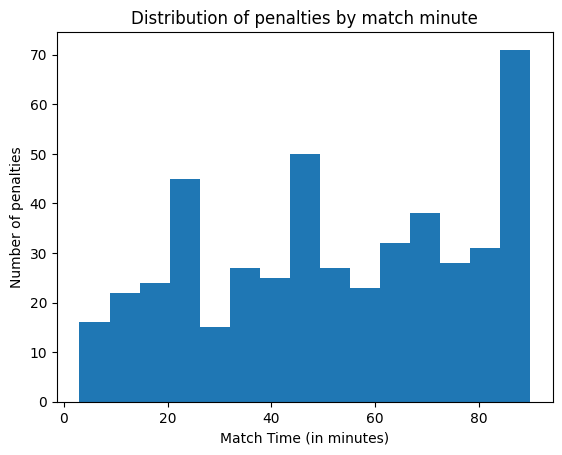

In [84]:
plt.hist(df["Minute"], bins = 15)
plt.title("Distribution of penalties by match minute")
plt.xlabel("Match Time (in minutes)")
plt.ylabel("Number of penalties")

Text(0, 0.5, 'Number of penalties')

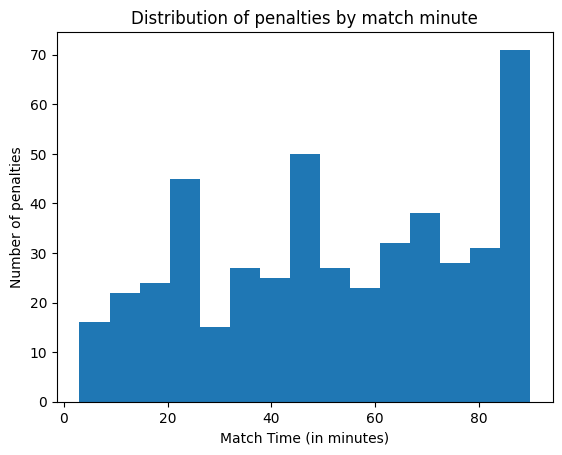

In [85]:
##ALITER##
fig, ax = plt.subplots()

ax.hist(df["Minute"], bins = 15)
ax.set_title("Distribution of penalties by match minute")
ax.set_xlabel("Match Time (in minutes)")
ax.set_ylabel("Number of penalties")

In [86]:
Home_Goal_Table = pd.DataFrame({
    "Maximum": [df["Home_Goals"].max()],
    "Minimum": [df["Home_Goals"].min()],
    "Average": [df["Home_Goals"].mean()],
    "Median": [df["Home_Goals"].median()]
})

Home_Goal_Table

,Maximum,Minimum,Average,Median
0,5,0,0.725738,0.0


In [98]:
Home_Goal_Value_Table = pd.DataFrame({
    "Count": df["Home_Goals"].value_counts()
})

Home_Goal_Value_Table

,Count
Home_Goals,
0,251
1,134
2,66
3,15
4,7
5,1


Text(0, 0.5, 'Number of penalties')

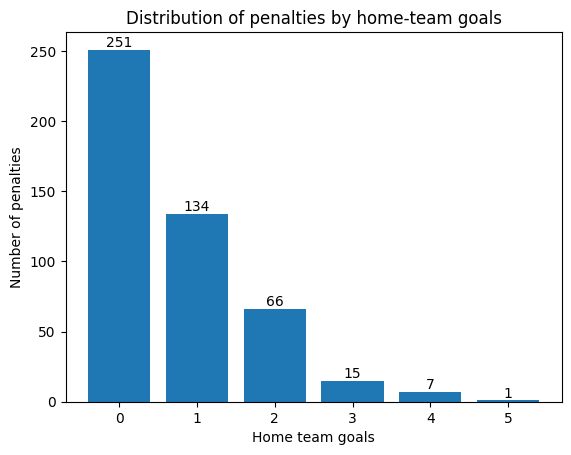

In [99]:
fig_HG, ax_HG = plt.subplots()

bars = ax_HG.bar(x = Home_Goal_Value_Table.index, height = Home_Goal_Value_Table["Count"])
ax_HG.bar_label(bars)

ax_HG.set_title("Distribution of penalties by home-team goals")
ax_HG.set_xlabel("Home team goals")
ax_HG.set_ylabel("Number of penalties")

In [91]:
Away_Goal_Table = pd.DataFrame({
    "Maximum": [df["Away_Goals"].max()],
    "Minimum": [df["Away_Goals"].min()],
    "Average": [df["Away_Goals"].mean()],
    "Median": [df["Away_Goals"].median()]
})

Away_Goal_Table

,Maximum,Minimum,Average,Median
0,4,0,0.64557,0.0


In [92]:
Away_Goal_Value_Table = pd.DataFrame({
    "Count": df["Away_Goals"].value_counts()
})

Away_Goal_Value_Table

,Count
Away_Goals,
0,257
1,147
2,53
3,15
4,2


Read each row as:

The away team had X goals at the time of the penalty in Y records.

So:

0 → 257 = 257 penalty records where the away team had 0 goals
1 → 147 = 147 penalty records where the away team had 1 goal
2 → 53 = 53 records where the away team had 2 goals
3 → 15 = 15 records where the away team had 3 goals
4 → 2 = 2 records where the away team had 4 goals

Text(0, 0.5, 'Number of penalties')

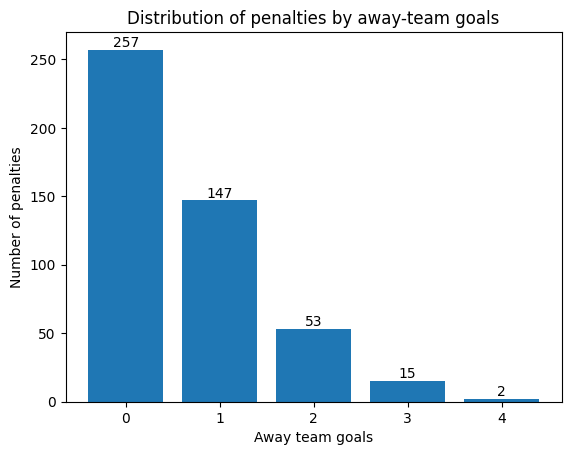

In [97]:
fig_AG, ax_AG = plt.subplots()

bars = ax_AG.bar(x = Away_Goal_Value_Table.index, height = Away_Goal_Value_Table["Count"])
ax_AG.bar_label(bars)

ax_AG.set_title("Distribution of penalties by away-team goals")
ax_AG.set_xlabel("Away team goals")
ax_AG.set_ylabel("Number of penalties")

In [96]:
Team_Type_Table = pd.DataFrame({
    "Count": df["Team_Type"].value_counts(),
    "Percentage": df["Team_Type"].value_counts(normalize=True)
})

Team_Type_Table

,Count,Percentage
Team_Type,,
H,260,0.548523
A,214,0.451477
